# BOREAS Velocity Visualization with ICP Processing

This notebook visualizes the linear and angular velocities estimated from LiDAR point cloud processing using ICP (Iterative Closest Point). It plots each velocity component (vx, vy, vz for linear; wx, wy, wz for angular) separately in a 3x2 figure layout, comparing estimated velocities with ground truth values.

In [7]:
import os
import sys

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from src.dataset.utils import LidarOdometryWrapper
from src.lidar_odometry.actor import LidarOdometryActor

In [9]:
# Initialize the LidarOdometryWrapper for ground truth velocities
# This automatically loads the dataset and applies rotation around z-axis by default
wrapper = LidarOdometryWrapper(seq_idx=0)

In [10]:
# Initialize the LidarOdometryActor for processing lidar clouds and estimating velocities
actor = LidarOdometryActor(config={})

In [11]:
# Process lidar clouds and store velocities
# We'll process the first N_FRAMES to build up velocity estimates
N_FRAMES = 500

# Get estimated velocities from the actor
estimated_velocities = []

# Iterate through frames, processing each lidar cloud
for i in range(N_FRAMES):
    # Get rotated LiDAR point cloud from the wrapper
    points = wrapper.get_lidar_point_cloud(i)

    # Get timestamp from the lidar frame
    lidar_frame = wrapper.seq.get_lidar(i)
    timestamp = lidar_frame.timestamp
    lidar_frame.unload_data()

    # Process the lidar cloud through the actor
    actor.process_lidar_cloud(points, timestamp)
    estimated_velocities.append( actor.get_current_velocities())

estimated_velocities = np.array(estimated_velocities)

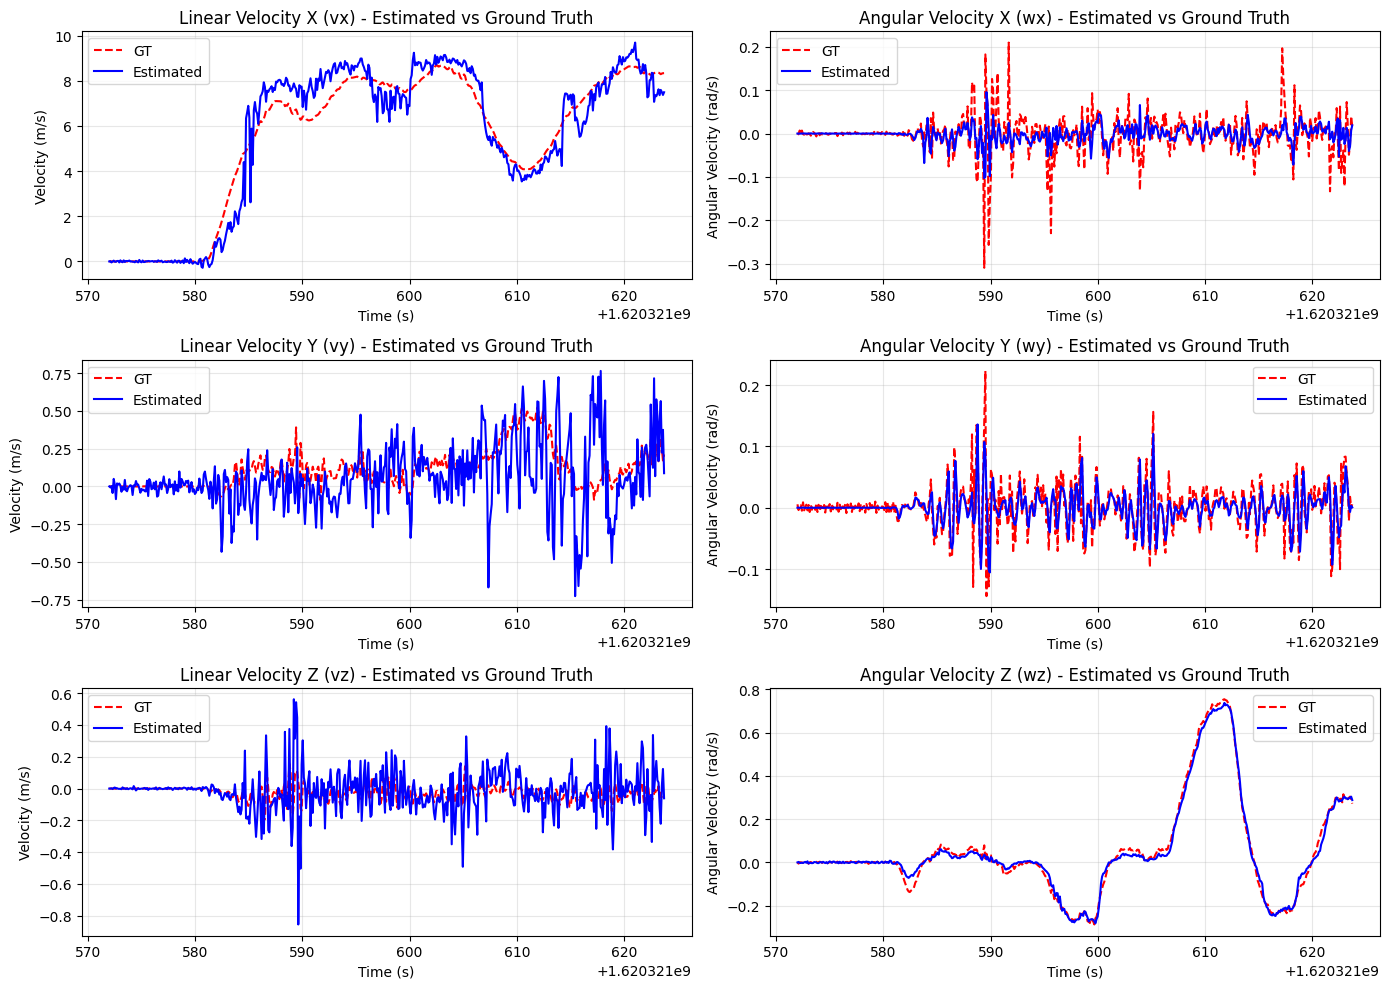

In [14]:
# Initialize lists to store velocity data for plotting
vx_est_data = []
vy_est_data = []
vz_est_data = []
wx_est_data = []
wy_est_data = []
wz_est_data = []
t_data = []

# Get ground truth velocities from the wrapper
vx_gt_data = []
vy_gt_data = []
vz_gt_data = []
wx_gt_data = []
wy_gt_data = []
wz_gt_data = []

# Iterate through frames to collect both estimated and GT velocities
for i in range(N_FRAMES):
    # Get rotated velocities directly from the wrapper (ground truth)
    gt_velocities = wrapper.get_velocities(i)
    
    vx_gt_data.append(gt_velocities[0])
    vy_gt_data.append(gt_velocities[1])
    vz_gt_data.append(gt_velocities[2])
    wx_gt_data.append(gt_velocities[3])
    wy_gt_data.append(gt_velocities[4])
    wz_gt_data.append(gt_velocities[5])
    
    # Get timestamp from the lidar frame
    lidar_frame = wrapper.seq.get_lidar(i)
    t_data.append(lidar_frame.timestamp)
    lidar_frame.unload_data()

# Create 3x2 figure layout for estimated vs ground truth velocities
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# First row: vx and wx - Estimated vs GT
axes[0, 0].plot(t_data, vx_gt_data, "r--", linewidth=1.5, label="GT")
axes[0, 0].plot(t_data, -estimated_velocities[:N_FRAMES][:, 3], "b-", linewidth=1.5, label="Estimated")
axes[0, 0].set_title("Linear Velocity X (vx) - Estimated vs Ground Truth")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Velocity (m/s)")
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_data, wx_gt_data, "r--", linewidth=1.5, label="GT")
axes[0, 1].plot(t_data, -estimated_velocities[:N_FRAMES][:, 0], "b-", linewidth=1.5, label="Estimated")
axes[0, 1].set_title("Angular Velocity X (wx) - Estimated vs Ground Truth")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Angular Velocity (rad/s)")
axes[0, 1].legend(loc='best')
axes[0, 1].grid(True, alpha=0.3)

# Second row: vy and wy - Estimated vs GT
axes[1, 0].plot(t_data, vy_gt_data, "r--", linewidth=1.5, label="GT")
axes[1, 0].plot(t_data, -estimated_velocities[:N_FRAMES][:, 4], "b-", linewidth=1.5, label="Estimated")
axes[1, 0].set_title("Linear Velocity Y (vy) - Estimated vs Ground Truth")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Velocity (m/s)")
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_data, wy_gt_data, "r--", linewidth=1.5, label="GT")
axes[1, 1].plot(t_data, -estimated_velocities[:N_FRAMES][:, 1], "b-", linewidth=1.5, label="Estimated")
axes[1, 1].set_title("Angular Velocity Y (wy) - Estimated vs Ground Truth")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Angular Velocity (rad/s)")
axes[1, 1].legend(loc='best')
axes[1, 1].grid(True, alpha=0.3)

# Third row: vz and wz - Estimated vs GT
axes[2, 0].plot(t_data, vz_gt_data, "r--", linewidth=1.5, label="GT")
axes[2, 0].plot(t_data, -estimated_velocities[:N_FRAMES][:, 5], "b-", linewidth=1.5, label="Estimated")
axes[2, 0].set_title("Linear Velocity Z (vz) - Estimated vs Ground Truth")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Velocity (m/s)")
axes[2, 0].legend(loc='best')
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(t_data, wz_gt_data, "r--", linewidth=1.5, label="GT")
axes[2, 1].plot(t_data, -estimated_velocities[:N_FRAMES][:, 2], "b-", linewidth=1.5, label="Estimated")
axes[2, 1].set_title("Angular Velocity Z (wz) - Estimated vs Ground Truth")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("Angular Velocity (rad/s)")
axes[2, 1].legend(loc='best')
axes[2, 1].grid(True, alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the figure
plt.show()